# Data Analysis & EDA
### German Traffic Sign Dataset (GTSRB)

## Step 1 — Install libraries

In [1]:
!pip install tensorflow tensorflow-datasets matplotlib seaborn scikit-learn scikit-image pillow --quiet

## Step 2 — Import libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from skimage.feature import hog
from skimage.color import rgb2gray
import tensorflow_datasets as tfds
import warnings
warnings.filterwarnings('ignore')
print('done')

done


## Step 3 — Download the dataset

In [3]:
import os
import cv2

def load_gtsrb(data_path, img_size=(32,32), test_size=0.2, random_state=42):
    images = []
    labels = []

    # Loop through class folders
    for label in sorted(os.listdir(data_path)):
        folder = os.path.join(data_path, label)
        # Skip if not a directory or not a number
        if not os.path.isdir(folder):
            continue
        if not label.isdigit():  # <-- skip non-numeric folders like "Meta"
            continue

        for img_name in os.listdir(folder):
            img_path = os.path.join(folder, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.resize(img, img_size)
            images.append(img)
            labels.append(int(label))

    X = np.array(images)
    y = np.array(labels)

    # Split into train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    train_ds = {"image": X_train, "label": y_train}
    test_ds  = {"image": X_test, "label": y_test}

    return train_ds, test_ds

In [4]:
data_path = "/kaggle/input/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/Train"

train_ds, test_ds = load_gtsrb(data_path)

print("Train images:", train_ds["image"].shape)
print("Train labels:", train_ds["label"].shape)
print("Test images:", test_ds["image"].shape)
print("Test labels:", test_ds["label"].shape)

Train images: (31367, 32, 32, 3)
Train labels: (31367,)
Test images: (7842, 32, 32, 3)
Test labels: (7842,)


## Step 4 — Convert to numpy arrays
We resize every image to 32x32 so they are all the same size.

In [6]:
x_train, y_train = train_ds["image"], train_ds["label"]
x_test,  y_test  = test_ds["image"],  test_ds["label"]

print("train shape:", x_train.shape)
print("test shape: ", x_test.shape)

train shape: (31367, 32, 32, 3)
test shape:  (7842, 32, 32, 3)


## Step 5 — Class names

In [7]:
names = [
    'Speed 20', 'Speed 30', 'Speed 50', 'Speed 60', 'Speed 70',
    'Speed 80', 'End Speed 80', 'Speed 100', 'Speed 120', 'No Passing',
    'No Passing 3.5t', 'Right of Way', 'Priority Road', 'Yield', 'Stop',
    'No Vehicles', 'No Vehicles 3.5t', 'Do Not Enter', 'Caution', 'Curve Left',
    'Curve Right', 'Double Curve', 'Bumpy Road', 'Slippery', 'Road Narrows',
    'Road Work', 'Traffic Signal', 'Pedestrians', 'Children', 'Bicycles',
    'Ice Snow', 'Wild Animals', 'End Restrictions', 'Turn Right', 'Turn Left',
    'Ahead Only', 'Ahead or Right', 'Ahead or Left', 'Keep Right', 'Keep Left',
    'Roundabout', 'End No Passing', 'End No Passing 3.5t'
]
print('total classes:', len(names))

total classes: 43


## Step 6 — Basic info

In [8]:
print('training images :', x_train.shape[0])
print('test images     :', x_test.shape[0])
print('image size      :', x_train.shape[1], 'x', x_train.shape[2])
print('color channels  :', x_train.shape[3])
print('min pixel       :', x_train.min())
print('max pixel       :', x_train.max())

training images : 31367
test images     : 7842
image size      : 32 x 32
color channels  : 3
min pixel       : 0
max pixel       : 255


## Step 7 — Show one image from each class

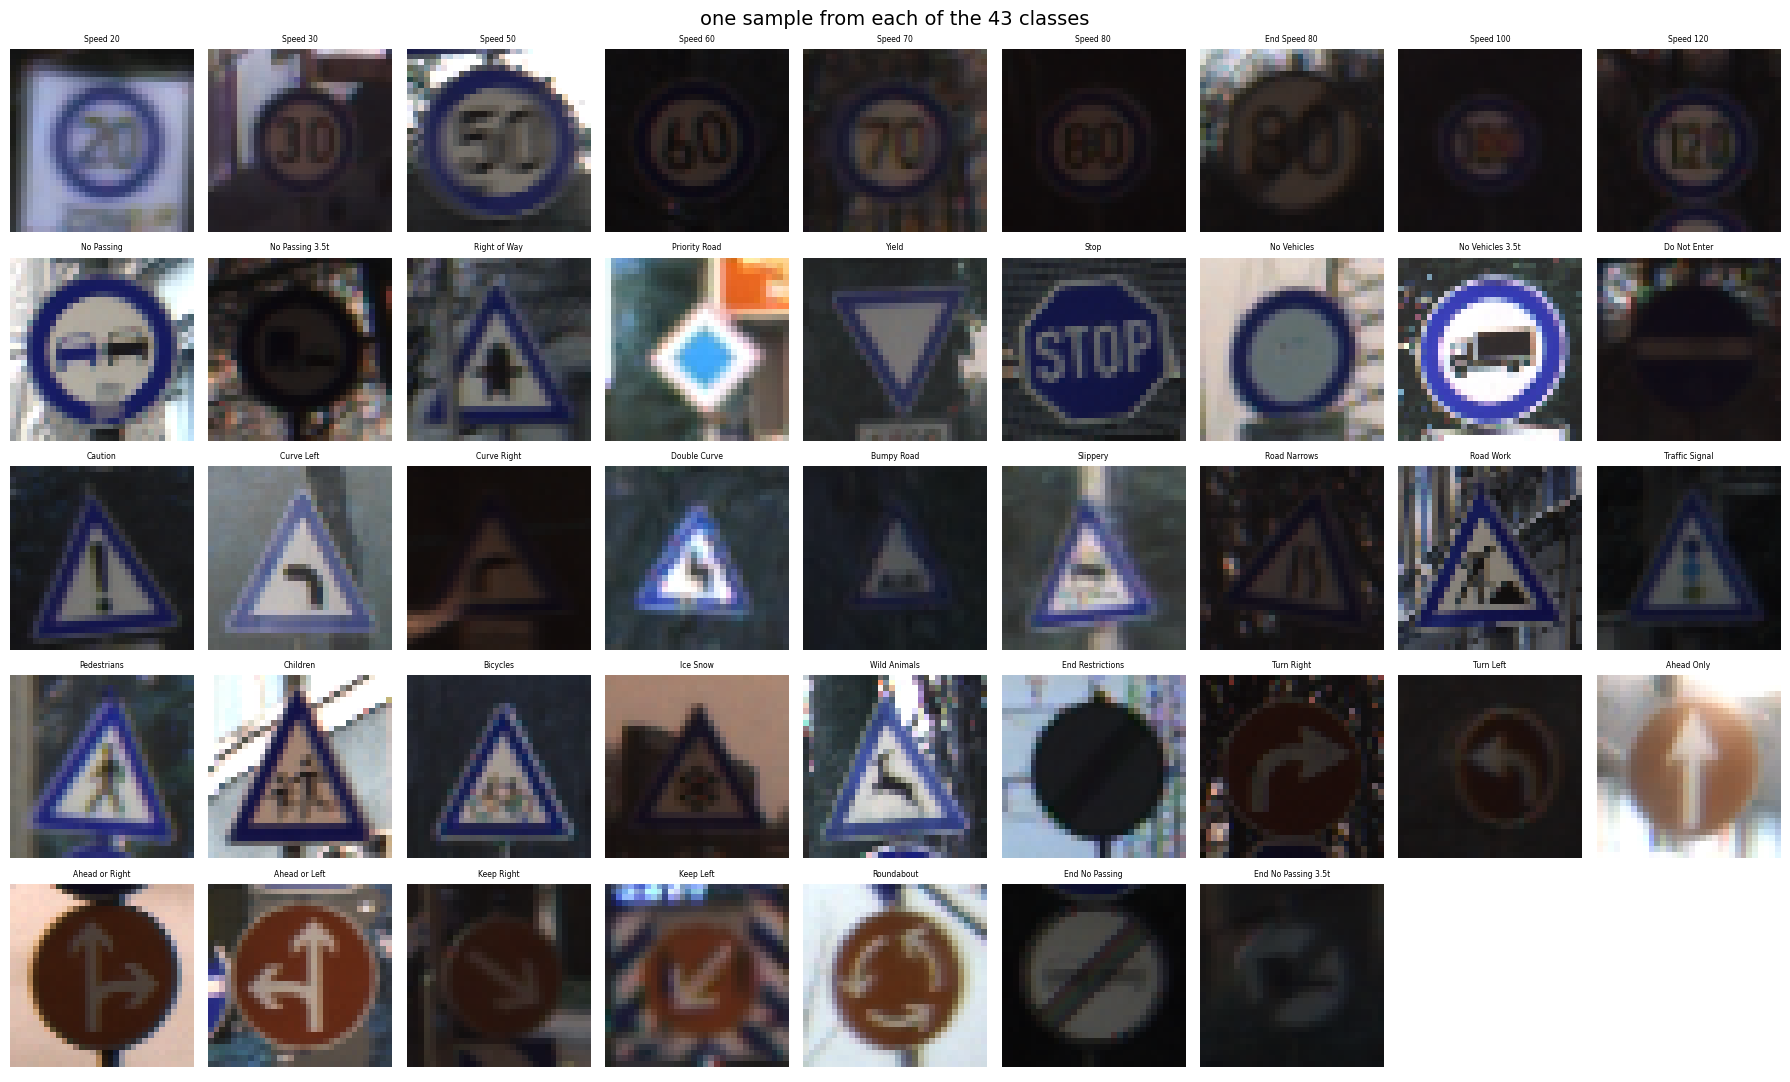

In [9]:
fig, axes = plt.subplots(5, 9, figsize=(18, 11))
fig.suptitle('one sample from each of the 43 classes', fontsize=14)

for i in range(43):
    ax = axes[i // 9][i % 9]
    idx = np.where(y_train == i)[0][0]
    ax.imshow(x_train[idx])
    ax.set_title(names[i], fontsize=5.5)
    ax.axis('off')

axes[4][7].axis('off')
axes[4][8].axis('off')
plt.tight_layout()
plt.savefig('sample_images.png', dpi=100)
plt.show()

## Step 8 — Class balance

In [10]:
ids, counts = np.unique(y_train, return_counts=True)

df = pd.DataFrame({'class id': ids, 'name': names, 'count': counts})
print(df.to_string(index=False))
print()
print('most common  :', names[counts.argmax()], '-', counts.max(), 'images')
print('least common :', names[counts.argmin()], '-', counts.min(), 'images')
print('ratio        :', round(counts.max() / counts.min(), 1), 'x')

 class id                name  count
        0            Speed 20    168
        1            Speed 30   1776
        2            Speed 50   1800
        3            Speed 60   1128
        4            Speed 70   1584
        5            Speed 80   1488
        6        End Speed 80    336
        7           Speed 100   1152
        8           Speed 120   1128
        9          No Passing   1176
       10     No Passing 3.5t   1608
       11        Right of Way   1056
       12       Priority Road   1680
       13               Yield   1728
       14                Stop    624
       15         No Vehicles    504
       16    No Vehicles 3.5t    336
       17        Do Not Enter    888
       18             Caution    960
       19          Curve Left    168
       20         Curve Right    288
       21        Double Curve    264
       22          Bumpy Road    312
       23            Slippery    408
       24        Road Narrows    216
       25           Road Work   1200
 

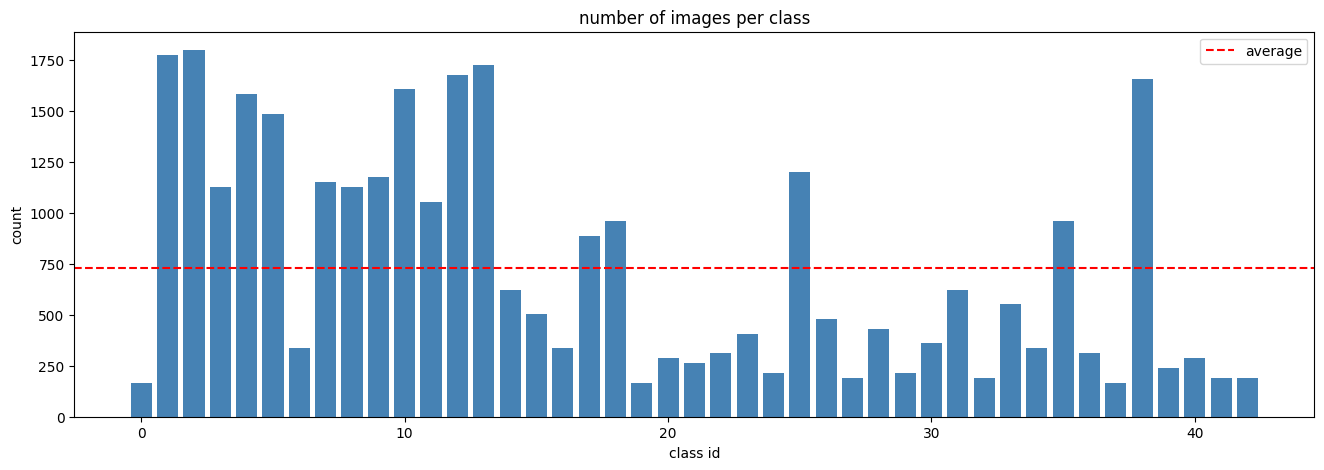

In [11]:
plt.figure(figsize=(16, 5))
plt.bar(ids, counts, color='steelblue')
plt.axhline(counts.mean(), color='red', linestyle='--', label='average')
plt.title('number of images per class')
plt.xlabel('class id')
plt.ylabel('count')
plt.legend()
plt.savefig('class_balance.png', dpi=100)
plt.show()

## Step 9 — Pixel statistics

In [12]:
print('average brightness :', round(x_train.mean(), 2))
print('std deviation      :', round(x_train.std(), 2))
print('red mean           :', round(x_train[:,:,:,0].mean(), 2))
print('green mean         :', round(x_train[:,:,:,1].mean(), 2))
print('blue mean          :', round(x_train[:,:,:,2].mean(), 2))

average brightness : 82.62
std deviation      : 68.94
red mean           : 81.79
green mean         : 79.45
blue mean          : 86.63


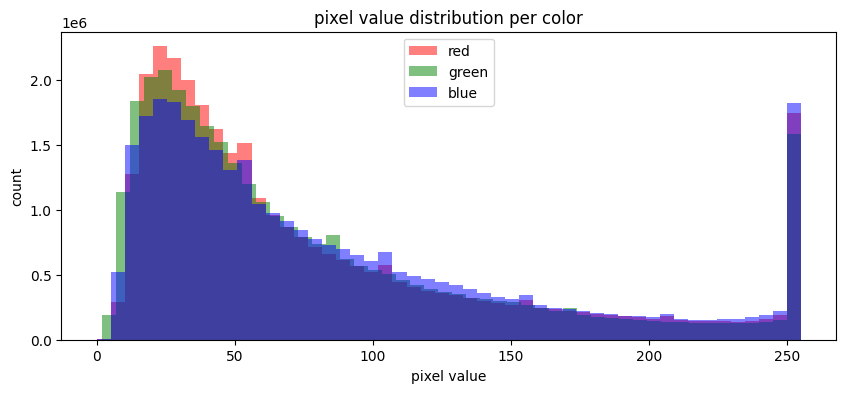

In [13]:
plt.figure(figsize=(10, 4))
plt.hist(x_train[:,:,:,0].flatten(), bins=50, color='red',   alpha=0.5, label='red')
plt.hist(x_train[:,:,:,1].flatten(), bins=50, color='green', alpha=0.5, label='green')
plt.hist(x_train[:,:,:,2].flatten(), bins=50, color='blue',  alpha=0.5, label='blue')
plt.title('pixel value distribution per color')
plt.xlabel('pixel value')
plt.ylabel('count')
plt.legend()
plt.savefig('pixel_distribution.png', dpi=100)
plt.show()

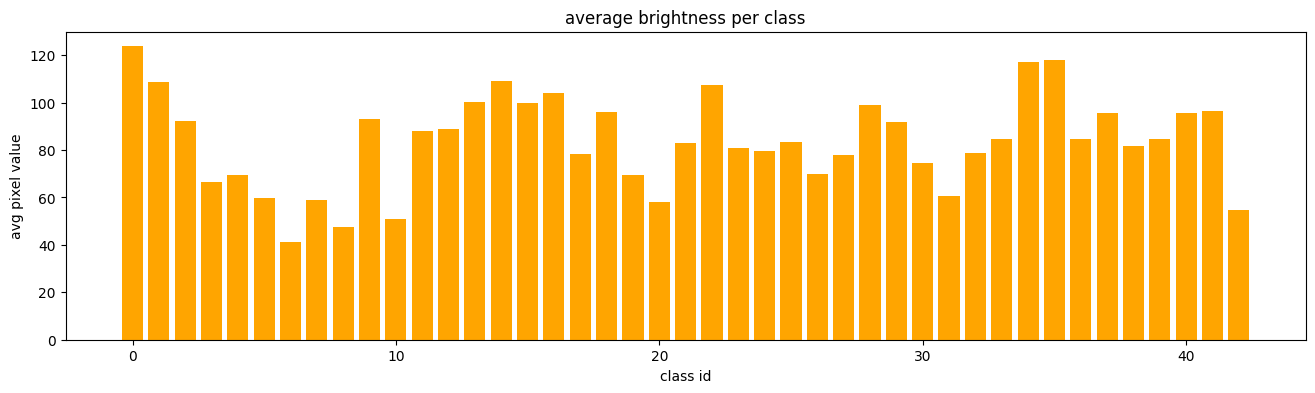

In [14]:
brightness = [x_train[y_train == i].mean() for i in range(43)]

plt.figure(figsize=(16, 4))
plt.bar(range(43), brightness, color='orange')
plt.title('average brightness per class')
plt.xlabel('class id')
plt.ylabel('avg pixel value')
plt.savefig('brightness_per_class.png', dpi=100)
plt.show()

## Step 10 — Data health check

In [15]:
print('nan values?          :', np.isnan(x_train.astype(float)).any())
print('all black images     :', (x_train.mean(axis=(1,2,3)) == 0).sum())
print('all white images     :', (x_train.mean(axis=(1,2,3)) == 255).sum())
print('min label value      :', y_train.min())
print('max label value      :', y_train.max())
print('unique classes found :', len(np.unique(y_train)))
print('pixel type           :', x_train.dtype)
print()
print('data is clean!')

nan values?          : False
all black images     : 0
all white images     : 0
min label value      : 0
max label value      : 42
unique classes found : 43
pixel type           : uint8

data is clean!


## Step 11 — Mean image per class

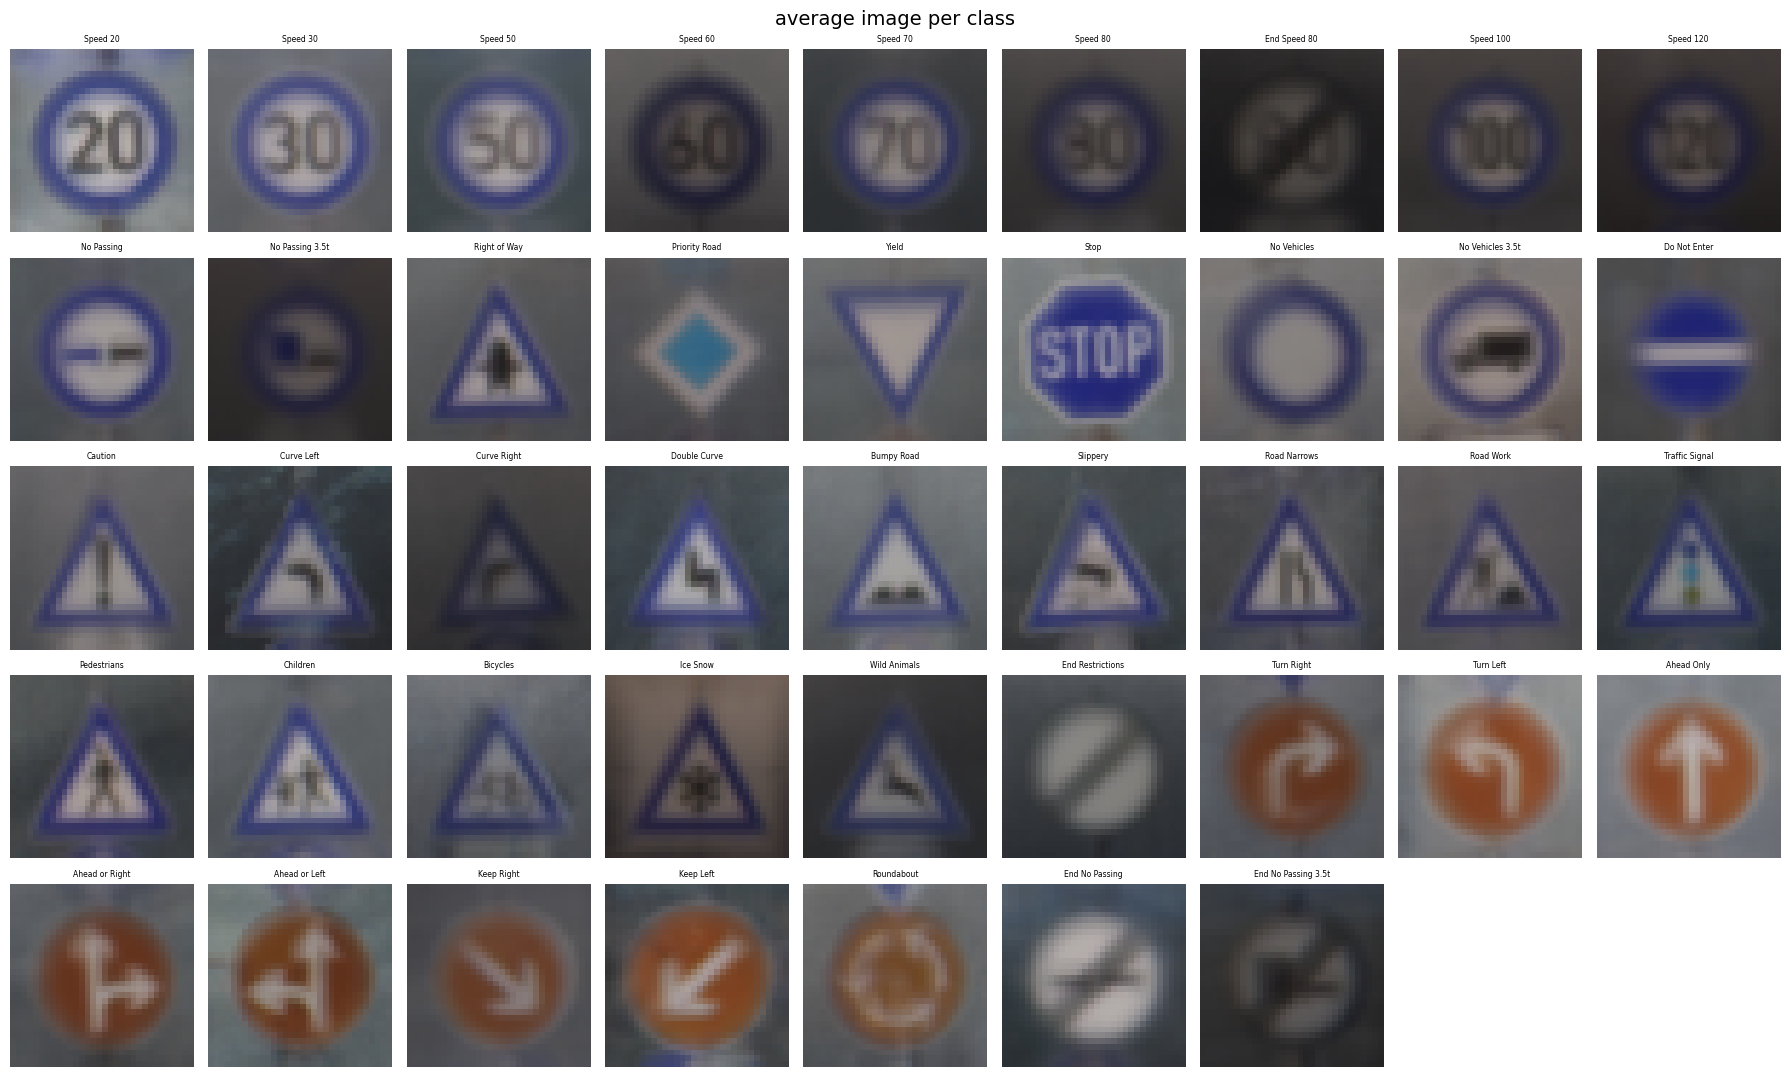

In [16]:
fig, axes = plt.subplots(5, 9, figsize=(18, 11))
fig.suptitle('average image per class', fontsize=14)

for i in range(43):
    ax = axes[i // 9][i % 9]
    mean_img = x_train[y_train == i].mean(axis=0).astype(np.uint8)
    ax.imshow(mean_img)
    ax.set_title(names[i], fontsize=5.5)
    ax.axis('off')

axes[4][7].axis('off')
axes[4][8].axis('off')
plt.tight_layout()
plt.savefig('mean_images.png', dpi=100)
plt.show()

In [17]:
import sys

# Add the helper folder from your dataset to Python path
sys.path.append("/kaggle/input/datasets/baselhelayel/helper")

## Step 12 — Feature extraction (feature_extraction.py)

In [18]:
from feature_extraction import FeatureExtractor
print('imported')

imported


In [19]:
sample_idx = []
for i in range(43):
    idx = np.where(y_train == i)[0][:12]
    sample_idx.extend(idx)

x_small = x_train[sample_idx]
y_small = y_train[sample_idx]

fe = FeatureExtractor(resize=(32, 32))
x_features = fe.extract_from_list(list(x_small))

print('features shape:', x_features.shape)

features shape: (516, 420)


## Step 13 — HOG visualization

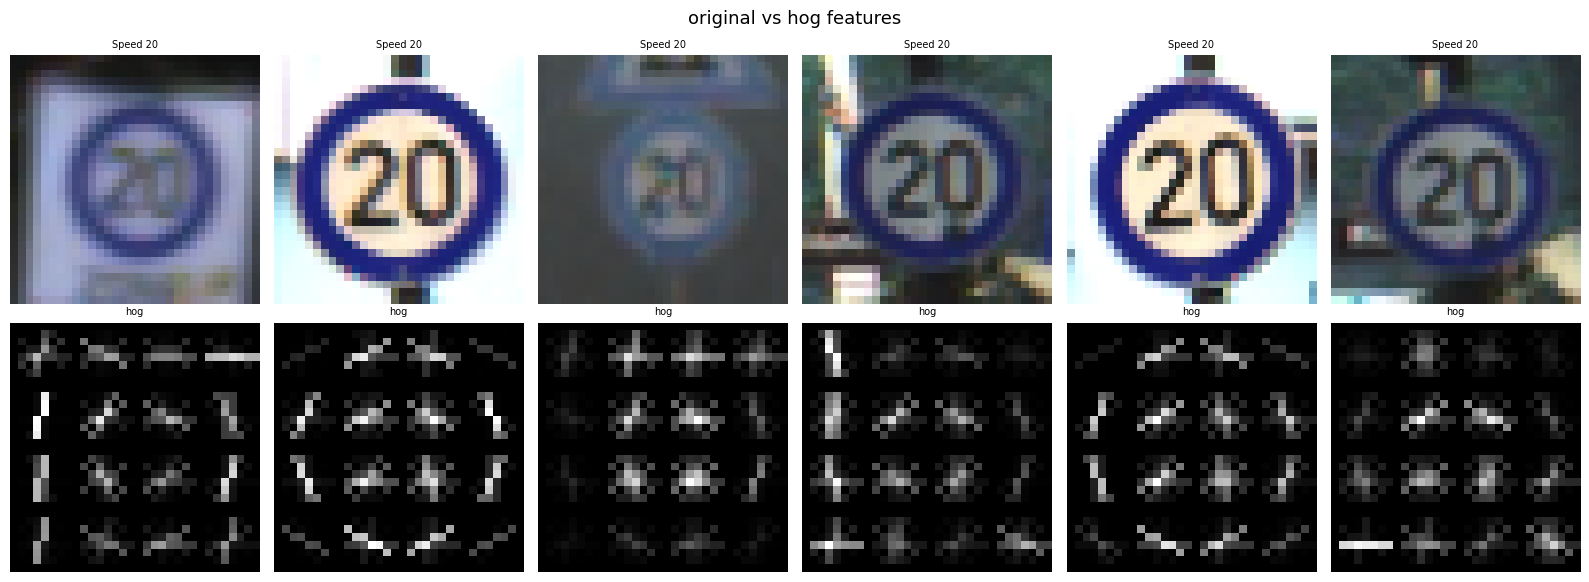

In [20]:
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
fig.suptitle('original vs hog features', fontsize=13)

for i in range(6):
    img = x_small[i]
    gray = rgb2gray(img)
    _, hog_img = hog(gray, visualize=True)

    axes[0][i].imshow(img)
    axes[0][i].set_title(names[y_small[i]], fontsize=7)
    axes[0][i].axis('off')

    axes[1][i].imshow(hog_img, cmap='gray')
    axes[1][i].set_title('hog', fontsize=7)
    axes[1][i].axis('off')

plt.tight_layout()
plt.savefig('hog_features.png', dpi=100)
plt.show()

## Step 14 — PCA (PCA.py)

In [21]:
from PCA import PCA_FromScratch
print('imported')

imported


In [22]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_features)

pca = PCA_FromScratch(n_components=2)
pca.fit(x_scaled)
x_2d = pca.transform(x_scaled)

print('reduced from', x_features.shape[1], 'features to 2')

reduced from 420 features to 2


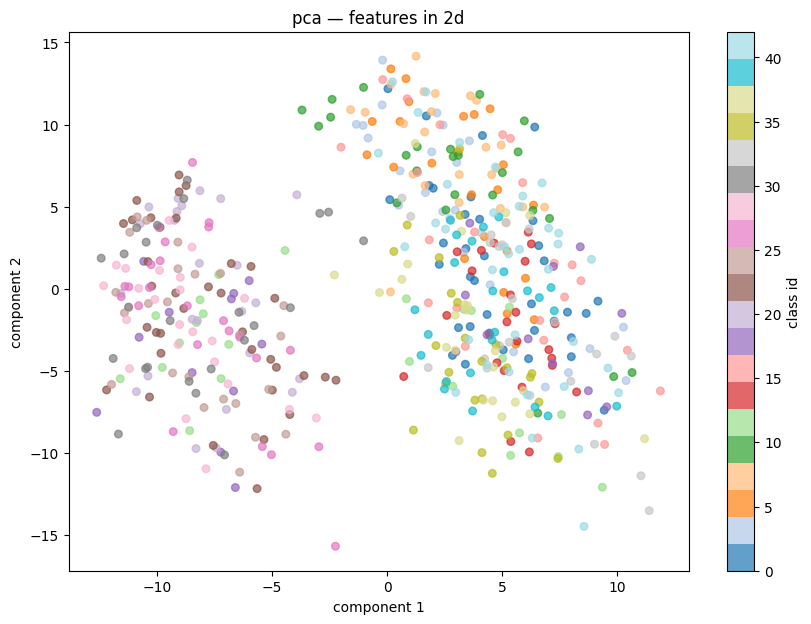

In [23]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(x_2d[:, 0], x_2d[:, 1], c=y_small, cmap='tab20', s=30, alpha=0.7)
plt.colorbar(scatter, label='class id')
plt.title('pca — features in 2d')
plt.xlabel('component 1')
plt.ylabel('component 2')
plt.savefig('pca_plot.png', dpi=100)
plt.show()

## Step 15 — Baseline models (baselines.py)

In [24]:
from baselines import BaselineModels
print('imported')

imported


In [25]:
x_tr, x_te, y_tr, y_te = train_test_split(x_features, y_small, test_size=0.25, random_state=42)

model = BaselineModels(knn_k=5, use_scaler=True, use_pca=False)
model.fit(x_tr, y_tr)

knn_res = model.evaluate(x_te, y_te, model='knn')
nb_res  = model.evaluate(x_te, y_te, model='nb')

print('knn results:')
for k, v in knn_res.items():
    if k != 'confusion_matrix':
        print(' ', k, ':', round(v, 3))

print()
print('naive bayes results:')
for k, v in nb_res.items():
    if k != 'confusion_matrix':
        print(' ', k, ':', round(v, 3))

knn results:
  accuracy : 0.372
  precision : 0.459
  recall : 0.4
  f1 : 0.395

naive bayes results:
  accuracy : 0.364
  precision : 0.45
  recall : 0.429
  f1 : 0.379


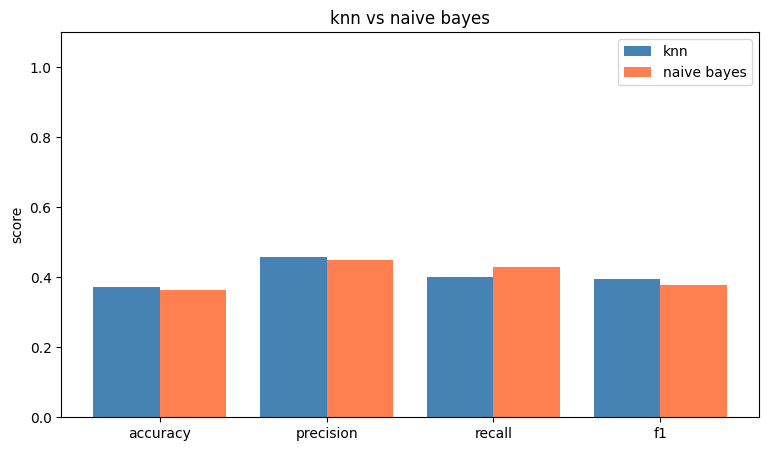

In [26]:
metrics = ['accuracy', 'precision', 'recall', 'f1']
knn_vals = [knn_res[m] for m in metrics]
nb_vals  = [nb_res[m]  for m in metrics]

x = np.arange(len(metrics))
plt.figure(figsize=(9, 5))
plt.bar(x - 0.2, knn_vals, 0.4, label='knn',         color='steelblue')
plt.bar(x + 0.2, nb_vals,  0.4, label='naive bayes', color='coral')
plt.xticks(x, metrics)
plt.ylim(0, 1.1)
plt.title('knn vs naive bayes')
plt.ylabel('score')
plt.legend()
plt.savefig('model_comparison.png', dpi=100)
plt.show()

## Step 16 — Confusion matrix

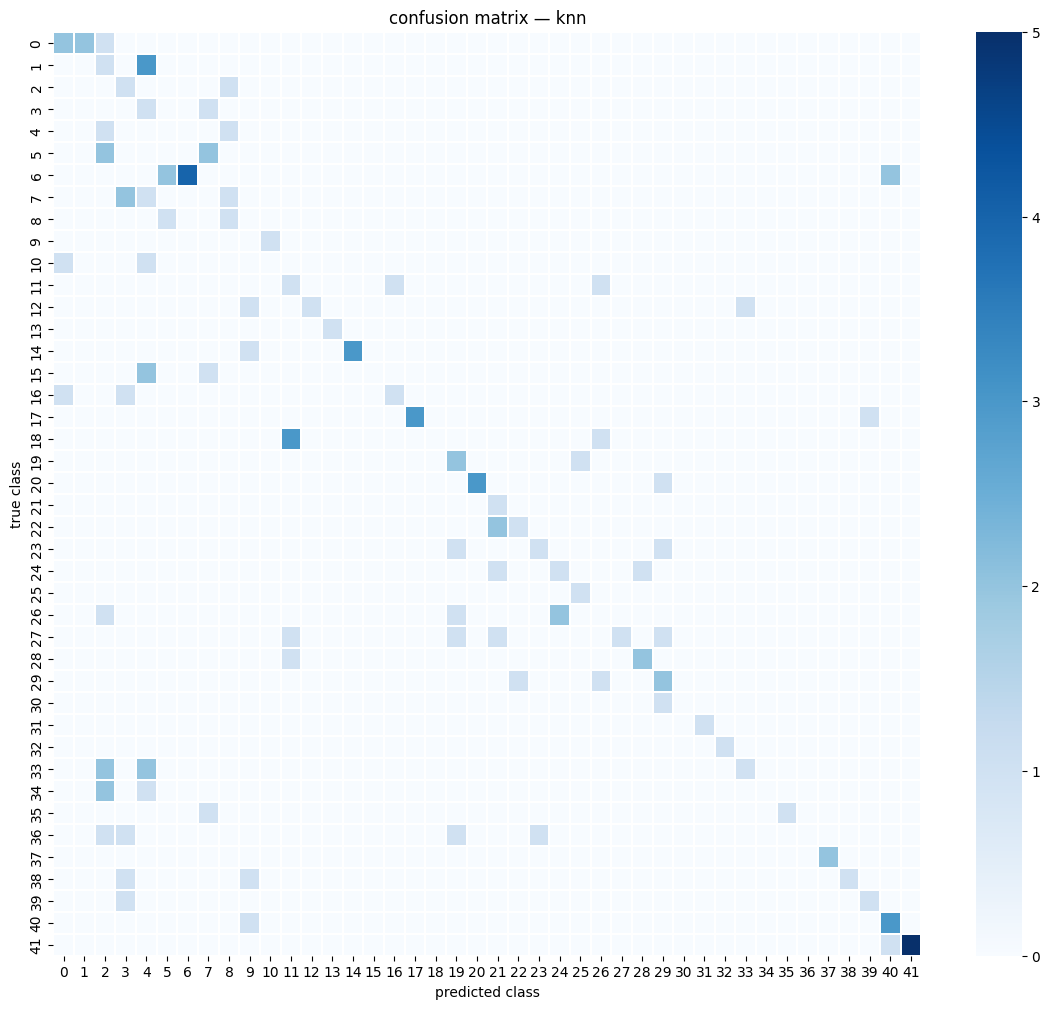

In [27]:
y_pred = model.predict(x_te, model='knn')
cm = confusion_matrix(y_te, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap='Blues', linewidths=0.3)
plt.title('confusion matrix — knn')
plt.xlabel('predicted class')
plt.ylabel('true class')
plt.savefig('confusion_matrix.png', dpi=100)
plt.show()

## Step 17 — Full pipeline (pipeline_example.py)

In [28]:
from pipeline_example import run_pipeline
print('imported')

imported


In [29]:
run_pipeline(images=list(x_small), labels=list(y_small))

KNN metrics:
  accuracy: 0.3798449612403101
  precision: 0.4613302372230943
  recall: 0.41547619047619044
  f1: 0.38482403062235
  confusion_matrix: [[0 0 0 ... 0 0 0]
 [2 1 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 4 0]
 [0 0 0 ... 0 1 3]]

Naive Bayes metrics:
  accuracy: 0.3023255813953488
  precision: 0.45089031339031344
  recall: 0.3861111111111112
  f1: 0.3373964047308995
  confusion_matrix: [[0 0 1 ... 0 0 0]
 [0 0 1 ... 1 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 2 0 0]
 [0 0 0 ... 2 2 0]
 [0 0 0 ... 4 1 0]]
